In [50]:
import sys
sys.path.insert(0, "/home/aronw/Development/Clans-3D")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import Scores_Evaluation.ScoresEvaluator as SE
from InputFileType import InputFileType
print(SE.__file__)

/home/aronw/Development/Clans-3D/Scores_Evaluation/ScoresEvaluator.py


In [52]:
# test-seeds for generated datasets: ["P68871", "Q99895", "P42212", "P00734", "P69905", "P0A6F5"]
PATH_TO_RECOVERED_CLANS = "/home/aronw/Development/clans-recovered" # path to old recovered clans project
CLUSTER_ROUNDS = 100000 # sets the number of rounds for clustering in recovered clans
EXAMPLE_GENERATED_DATA_SETS = {"dataset1": {"size_of_dataset": 30, "number_of_clusters": 1, "seeds": ["P68871"]}}
EXAMPLE_DATASET_FASTA = "/home/aronw/Development/Clans-3D/example_files/datasets_for_evaluation/datasets_fasta"
EXAMPLE_DATASET_TSV = "/home/aronw/Development/Clans-3D/example_files/datasets_for_evaluation/datasets_tsv"

In [53]:
evaluator = SE.ScoresEvaluator(PATH_TO_RECOVERED_CLANS)
structural_vs_sequence_dict = evaluator.initialize_evaluation(
        rounds_to_cluster=CLUSTER_ROUNDS,
        datasets_meta_data=None,
        use_existing_dataset=True,
        path_to_dir_of_existing_datasets=EXAMPLE_DATASET_FASTA,
        datasets_file_type=InputFileType.FASTA
    )

Initializing evaluation...
Failed to download https://alphafold.ebi.ac.uk/files/AF-NOTAVIALABLETEST-F1-model_v6.pdb: 404 Client Error: Not Found for url: https://alphafold.ebi.ac.uk/files/AF-NOTAVIALABLETEST-F1-model_v6.pdb
Downloaded 4 from 5 PDB files successfully.
Computing scores for dataset 5...
Computing structural similarity with foldseek...
Structural similarity computation with foldseek completed.
Generating CLANS file in /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim...
CLANS file generated at /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/5_cleaned.clans
Running recovered clans.jar on the generated structural clans files...
To honour the JVM settings for this build a single-use Daemon process will be forked. For more on this, please refer to https://docs.gradle.org/8.9/userguide/gradle_daemon.html#sec:disabling_the_daemon in the Gradle documentation.
Daemon will be stopped at the end of the build 
> Task :compileJava UP-TO-



Building a new DB, current time: 11/28/2025 17:36:47
New DB name:   /home/aronw/Development/Clans-3D/Scores_Evaluation/blast_files/temp_blast_db
New DB title:  /home/aronw/Development/Clans-3D/Scores_Evaluation/datasets/5_cleaned.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 4 sequences in 0.00673699 seconds.


   PDBchain1 PDBchain2          score
0     P29331    Q02346   0.000000e+00
1     P29331    P49811   0.000000e+00
2     P29331    Q90477  5.110000e-130
3     P49811    Q02346   0.000000e+00
4     P49811    P29331   0.000000e+00
5     P49811    Q90477  6.070000e-128
6     Q02346    P49811   0.000000e+00
7     Q02346    P29331  5.790000e-180
8     Q02346    Q90477  2.330000e-128
9     Q90477    P49811  6.970000e-127
10    Q90477    Q02346  1.270000e-123
11    Q90477    P29331  1.460000e-123
Generating CLANS file in /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim...
CLANS file generated at /home/

Evaluating structural clans file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/5_cleaned_out.clans with sequence clans file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim/5_cleaned_out.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/5_cleaned_out.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim/5_cleaned_out.clans...
   PDBchain1  PDBchain2  score_struct      score_seq  score_struct_log10  \
0          0          1  1.487000e-31   0.000000e+00           30.827689   
1          0          2  1.521000e-29   0.000000e+00           28.817871   
2          0          3  7.902000e-19  5.110000e-130           18.102263   
3          1          2  5.216000e-42   0.000000e+00           41.282662   
4          1          3  1.061000e-27  6.070000e-128           26.974285   
5          2          3  3.222000e-28  2.330000e-128           27.491874 

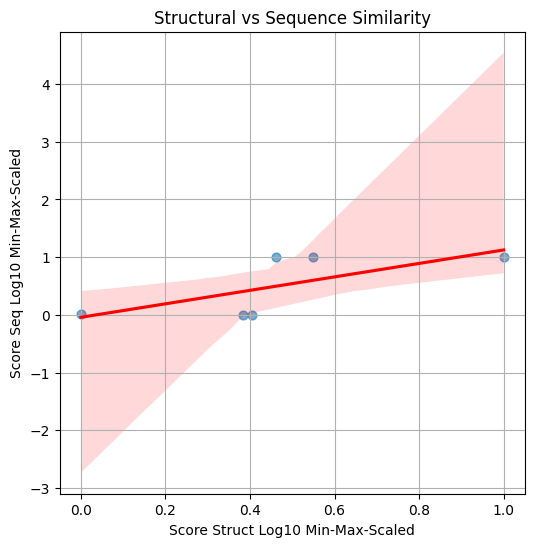

In [54]:
evaluation_results_df = evaluator.evaluate(structural_vs_sequence_dict)